# S5: Phonetics and phonology — solutions

Run this notebook from the `S5` folder with the `cpes_3.12` kernel. The audio recording and vowel data are included here.


In [1]:
from IPython.display import Audio, display # play audio in the notebook
import soundfile as sf
import numpy as np # numerical operations
import matplotlib.pyplot as plt # plotting
import seaborn as sns # plotting
import parselmouth # sound analysis
import pandas as pd # dataframe manipulation

sns.set(context='paper', style='ticks', font_scale=1) # set the plot style

## 1. Soundwave

### 1.1. Basic properties: frequency and amplitude

Let's start by generating a sound wave. For that, we need to define its frequency and amplitude. The frequency is the number of cycles per second, and the amplitude is the maximum displacement of the wave from its equilibrium position.

In [2]:
FREQUENCY = 10 # measured in Hz
AMPLITUDE = 100 # measured in relative units
DURATION = 1 # measured in seconds

Since sound is continuous, we need to record it somehow. We can sample 44100 points per second, which is the standard sampling rate for audio CDs: 

In [3]:
t = np.linspace(0, DURATION, int(44100 * DURATION), 
                endpoint=False) # time variable (44100 samples per second)

Let's check whether t vector has the correct size:

In [4]:
t.shape

(44100,)

Let's now create the sin wave using the formula:

$$y(t) = A \sin(2\pi f t)$$

where:

- $A$ is the amplitude of the wave
- $f$ is the frequency of the wave
- $t$ is the time

Essentially it determines the position of the wave at a given time. The amplitude determines the height of the wave, and the frequency determines how many times the wave repeats in a given time frame. 2 * pi is used because the vawe can be represented as a circle.

![Sound wave](https://europe1.discourse-cdn.com/unity/original/3X/1/6/16042a63a17ef2b18ddf4b01d5e9ae26151b4845.gif)

Implement this equation in Python below:

In [5]:
wave = AMPLITUDE * np.sin(2 * np.pi * FREQUENCY * t)
wave.round(2) # smoothing a little

array([ 0.  ,  0.14,  0.28, ..., -0.43, -0.28, -0.14])

In [6]:
wave.max()

99.99997462578868

Let's play it to check if it is working:

In [7]:
display(Audio(wave, rate=44100)) # play the sound in the notebook


Let's save the wave:

In [8]:
sf.write('sine_wave_1.wav', wave, 44100) # save the wave using soundfile

Finally, let's plot the wave:

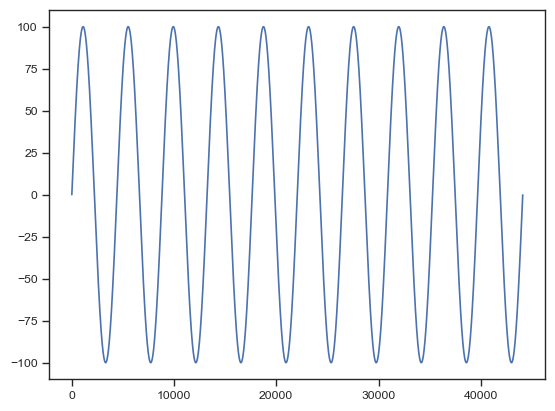

In [9]:
plt.plot(wave)

Ok, great. Can you npow add vertical lines to the plot to show the period of the wave? Remember that frequency is the number of cycles per second, so you can extract the period points from frequency. You can use [plt.axvline](https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.axvline.html) to plot vertical lines. 

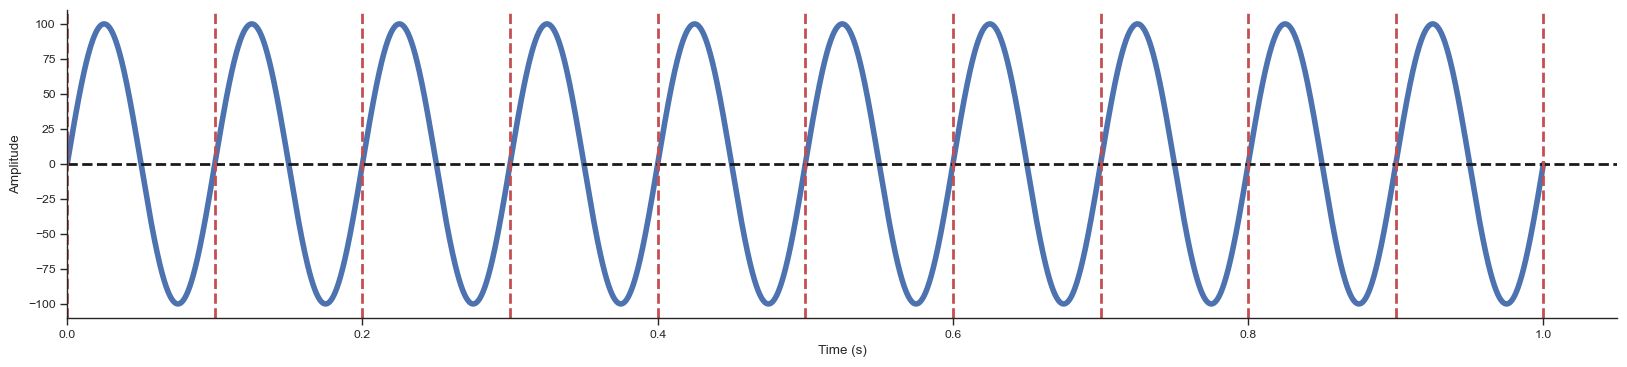

In [10]:
plt.figure(figsize=(20, 4))
plt.plot(t, wave, linewidth=4)
plt.xlabel('Time (s)')
plt.ylabel('Amplitude')
# indicate frequency as intercection of the wave with the x-axis
plt.axhline(y=0, color='k', linestyle='--', linewidth=2)

# Frequency is the number of full waves in one second, so 
# we can delimit the full waves by dividing the duration by the frequency.
# In our case, the duration is 1 second and the frequency is 4 Hz, so we have 4 full waves in 1 second.
for _ in range(FREQUENCY + 1): 
    plt.axvline(x=_/FREQUENCY, color='r', linestyle='--', linewidth=2)

plt.xlim(-0, None)
sns.despine()
plt.show()

We can also find the crest by finding time points where the wave value is equal to amplitude (hint: you need x and y coordinates:

In [11]:
crest_x = np.where(wave == wave.max())[0]
crest_y = np.max(wave)

Now let's plot the wave with the crest:

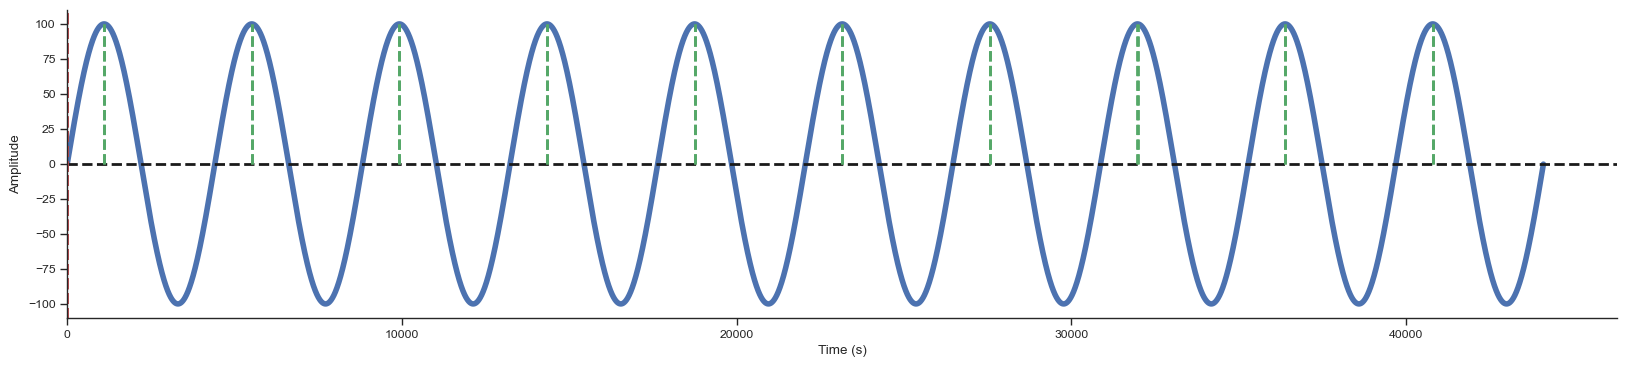

In [88]:
plt.figure(figsize=(20, 4))
plt.plot(wave, linewidth=4)
plt.xlabel('Time (s)')
plt.ylabel('Amplitude')
# indicate frequency as intercection of the wave with the x-axis
plt.axhline(y=0, color='k', linestyle='--', linewidth=2)

# delimit full waves
plt.axvline(x=0, color='r', linestyle='--')
# Frequency is the number of full waves in one second, so 
# we can delimit the full waves by dividing the duration by frequency.
# In our case, the duration is 1 second and the frequency is 4 Hz, so we have 4 full waves in 1 second.
for _ in range(FREQUENCY + 1): 
    plt.axvline(x=_/FREQUENCY, color='r', linestyle='--', linewidth=2)

# plot the crest as a vertical line from y = 0 to the crest [crest_x, 0], [crest_x, AMPLITUDE]
plt.plot([crest_x, crest_x], [0, crest_y], 
         color='g', linestyle='--', linewidth=2)

plt.xlim(-0, None)
sns.despine()
plt.show()

### 1.2. Let's change the properties!

First, we will turn our sound generating mechanism into a function

In [13]:
def generate_sound(frequency, amplitude, duration, sample_rate = 44100):
    t = np.linspace(0, duration, int(sample_rate * duration), endpoint=False)
    return amplitude * np.sin(frequency * 2 * np.pi * t)

We would also need a function to play it

In [14]:
def play_sound(sound):
    display(Audio(sound, rate=44100))


Let's generate a sound with a higher frequency and a lower amplitude

In [15]:
c3 = generate_sound(frequency = 130, # do (C3) 
                       amplitude = 1, 
                       duration = 1)

Save the file:

In [16]:
sf.write('c3.wav', c3, 44100)

And play the sound:

In [17]:
play_sound(c3)

Finally, let's visualize the wave:

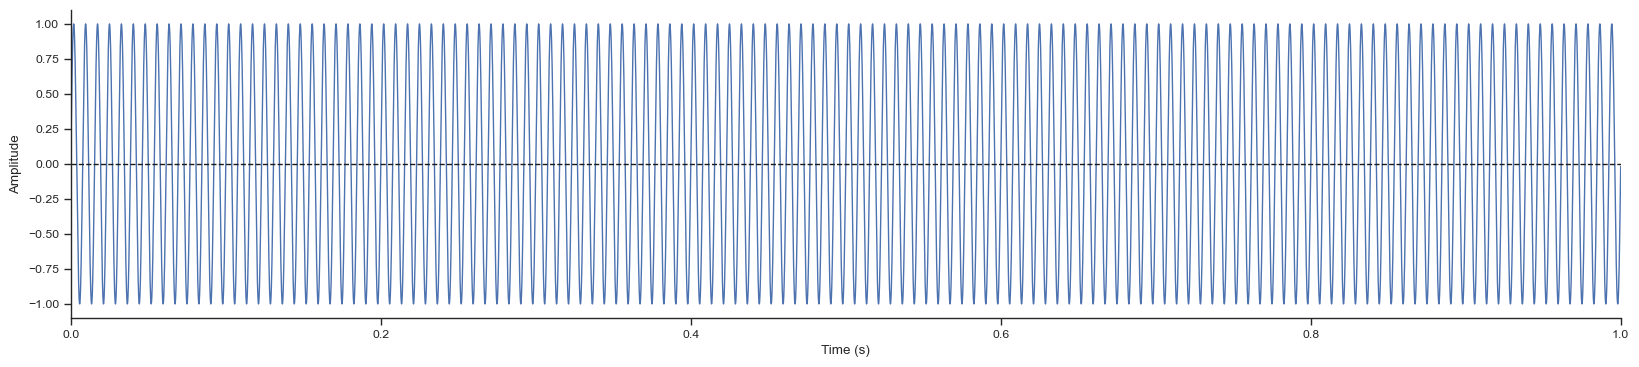

In [18]:
plt.figure(figsize=(20, 4))
plt.plot(t, c3, linewidth=1)
plt.xlabel('Time (s)')
plt.ylabel('Amplitude')

plt.axhline(y=0, color='k', linestyle='--', 
            linewidth=1)

plt.xlim(-0, 1)
sns.despine()

### 1.3. Combining different frequencies

Ok, now we know how to create individual waves. Let's combine them to create a more complex sound. We can do this by summing the waves -- write a function to generate a chord by summing three different sine waves with different frequencies and amplitudes. 

Inputs: frequencies (list of 3 frequencies), amplitudes (list of 3 amplitudes), duration (in seconds), sample_rate (default 44100)

Outputs: combined wave (numpy array)

In [19]:
def generate_chord(frequencies, 
                   amplitude, 
                   duration, 
                   sample_rate=44100):
    a1 = generate_sound(frequency=frequencies[0],
                        amplitude=amplitude,
                        duration=duration,
                        sample_rate=sample_rate)
    a2 = generate_sound(frequency=frequencies[1],
                        amplitude=amplitude,
                        duration=duration,
                        sample_rate=sample_rate)
    a3 = generate_sound(frequency=frequencies[2],
                        amplitude=amplitude,
                        duration=duration,
                        sample_rate=sample_rate)
    return a1 + a2 + a3

Why can we just add the waves? Let's try whether it works by generating the A minor chord:

**Answer:** Sound pressures add by superposition, so adding the sampled waves combines their frequencies into a chord.


In [20]:
a_minor = generate_chord(frequencies = [220, 262, 330], # A3, C4, E4
                       amplitude = 0.1, 
                       duration = 1)

Now let's also generate all the corresponding notes one by one:

In [21]:
s_220 = generate_sound(frequency = 220, # A4
                          amplitude = 1, 
                          duration = 1)
s_262 = generate_sound(frequency = 262, # C4
                            amplitude = 1, 
                            duration = 1)
s_330 = generate_sound(frequency = 330, # E4
                            amplitude = 1, 
                            duration = 1)

And write them to files:

In [22]:
sf.write('a3.wav', s_220, 44100)
sf.write('c4.wav', s_262, 44100)
sf.write('e4.wav', s_330, 44100)

Let's visualize all the 3 notes together:

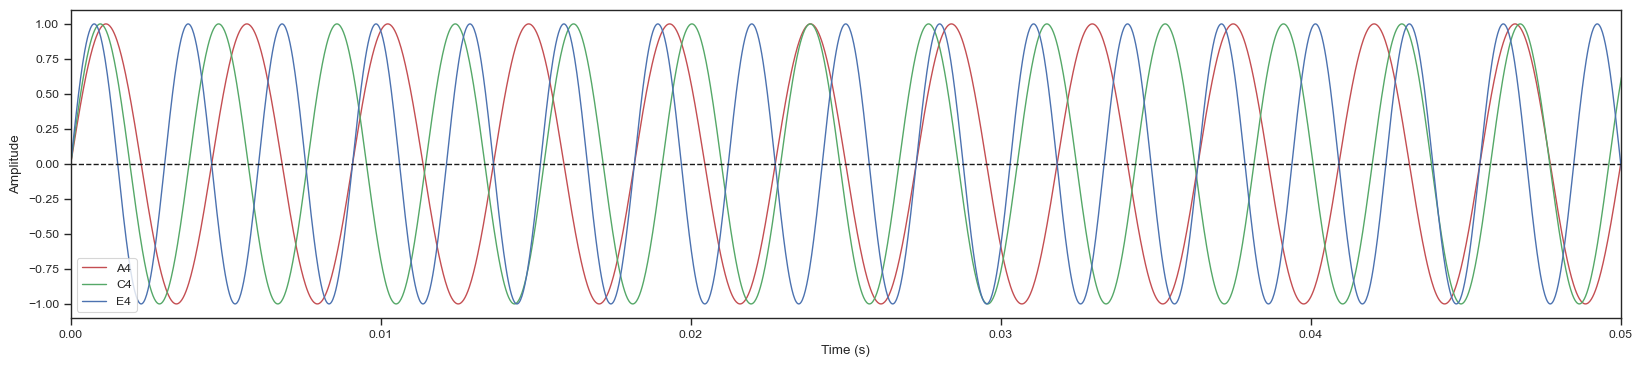

In [23]:
# plot the three sounds together
plt.figure(figsize=(20, 4))
plt.plot(t, s_220, linewidth=1, label='A4', color='r')
plt.plot(t, s_262, linewidth=1, label='C4', color='g')
plt.plot(t, s_330, linewidth=1, label='E4', color='b')
# add a line at 0
plt.axhline(y=0, color='k', linestyle='--', linewidth=1)
plt.xlim(0, 0.05)
plt.xlabel('Time (s)')
plt.ylabel('Amplitude')
plt.legend()
plt.show()

Finally, let's plot the chord on top:

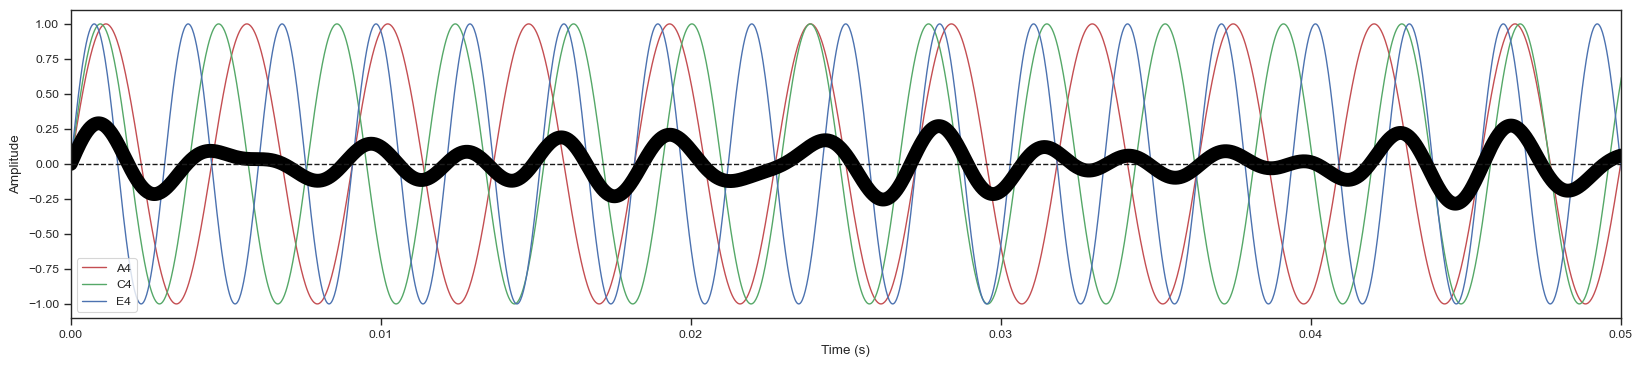

In [24]:
# plot the three sounds together
plt.figure(figsize=(20, 4))
plt.plot(t, s_220, linewidth=1, label='A4', color='r')
plt.plot(t, s_262, linewidth=1, label='C4', color='g')
plt.plot(t, s_330, linewidth=1, label='E4', color='b')
plt.plot(t, a_minor, linewidth=10, color='black')
# add a line at 0
plt.axhline(y=0, color='k', linestyle='--', linewidth=1)
plt.xlim(0, 0.05)
plt.xlabel('Time (s)')
plt.ylabel('Amplitude')
plt.legend()
plt.show()

To play the chord, you need to renormalise it for having a maximum amplitude of 1:

In [25]:
# renormalize the chord
a_minor = a_minor / np.max(a_minor)

Now let's see how it looks:

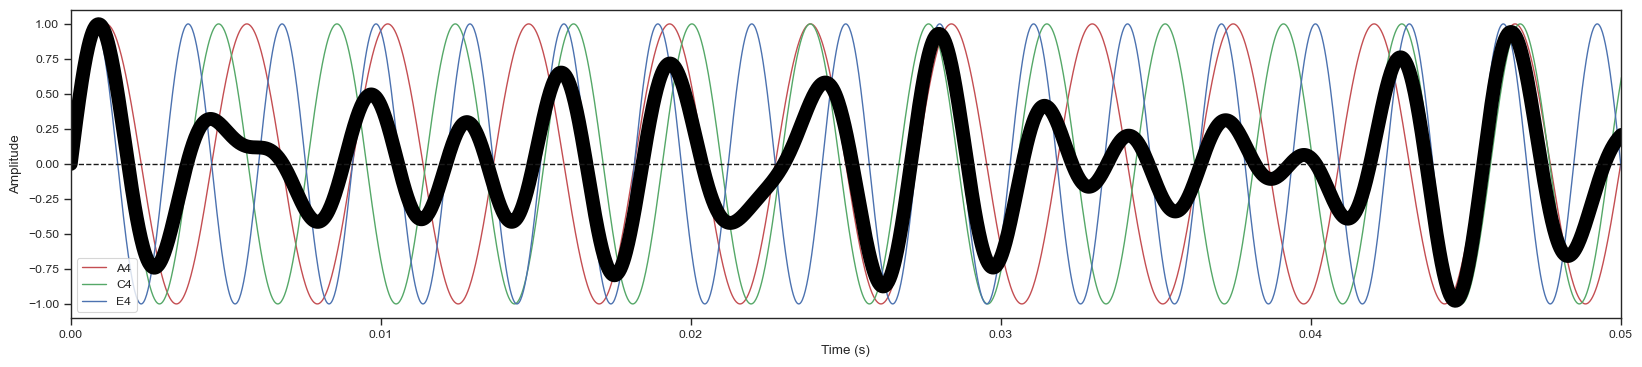

In [85]:
# plot the three sounds together
plt.figure(figsize=(20, 4))
plt.plot(t, s_220, linewidth=1, label='A4', color='r')
plt.plot(t, s_262, linewidth=1, label='C4', color='g')
plt.plot(t, s_330, linewidth=1, label='E4', color='b')
plt.plot(t, a_minor, linewidth=10, color='black')
# add a line at 0
plt.axhline(y=0, color='k', linestyle='--', linewidth=1)
plt.xlim(0, 0.05)
plt.xlabel('Time (s)')
plt.ylabel('Amplitude')
plt.legend()
plt.show()

In [26]:
play_sound(a_minor)

In [27]:
# save all the waves using soundfile
sf.write('a_minor.wav', a_minor, 44100)

Now let's play with vowels. A wovel is a sum of 3 formants (resonant frequencies). Let's generate an "ideal" vowel sound by summing 3 sine waves, that we'll extract from Praat:

In [28]:
a_Alexey = generate_chord(frequencies = [835, 1860, 2800], # A3, C4, E4
                       amplitude = 1, 
                       duration = 1)
# sf.write('a_A.wav', a_Alexey, 44100)

In [29]:
play_sound(a_Alexey)

## 2. Spectrograms

We will be relying on [parselmouth](https://parselmouth.readthedocs.io/en/stable/index.html) to generate the spectrograms and analyze them.

### 2.1. Spectrogram of a note

Let's plot the spectrogram of a note to understand how it works:

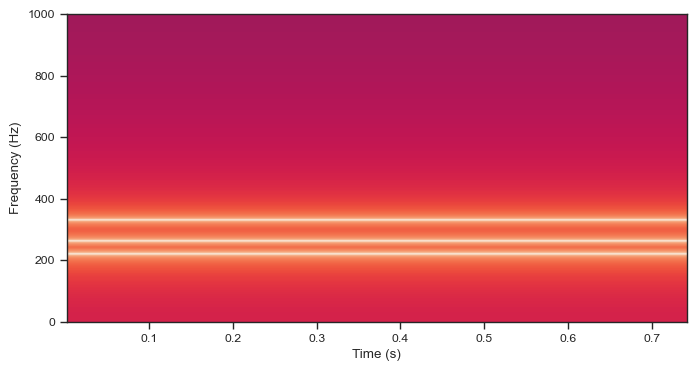

In [30]:
# convert sound to spectrogram  
plt.figure(figsize=(8, 4))
# only consider 0 -- 1000 hz
plt.specgram(a_minor, NFFT=2**15, Fs=44100) # 2**15 is the number of samples per window
plt.xlabel('Time (s)')
plt.ylabel('Frequency (Hz)')
plt.ylim(0, 1000)
plt.show()

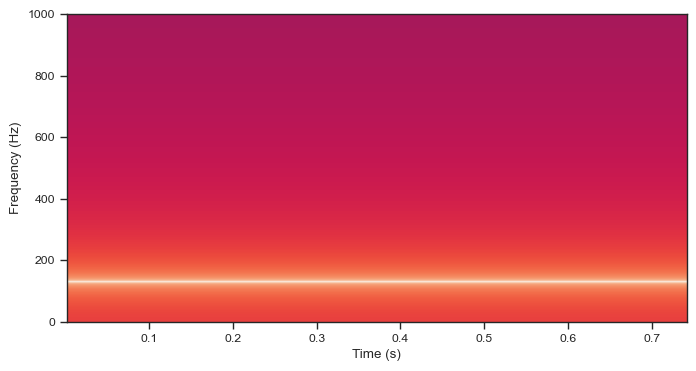

In [31]:
plt.figure(figsize=(8, 4))
# only consider 0 -- 1000 hz
plt.specgram(c3, NFFT=2**15, Fs=44100) # 2**15 is the number of samples per window
plt.xlabel('Time (s)')
plt.ylabel('Frequency (Hz)')
plt.ylim(0, 1000)
plt.show()

### 2.2. Spectrogram of speech

The recording `ta-ta-ta.wav` is included in this folder.


In [32]:
snd = parselmouth.Sound('ta-ta-ta.wav')

We can use our previously written function to play the sound:

In [33]:
play_sound(snd.values[0])

Let's plot the speech signal as a function of time and amplitude

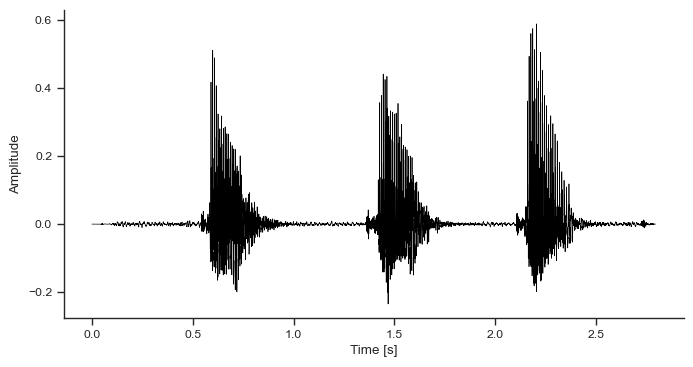

In [34]:
plt.figure(figsize=(8, 4)) # define the figure size
plt.plot(snd.xs(), snd.values.T, 
         linewidth=0.5, color='black') # plot the amplitude as a function of time
plt.xlabel("Time [s]") # set the x-axis label
plt.ylabel("Amplitude") # set the y-axis label
sns.despine() # remove the top and right spines (just for aesthetics)
plt.show() 

Let's create a function to plot the spectrogram:

In [35]:
def draw_spectrogram(spectrogram, dynamic_range=70):
    X, Y = spectrogram.x_grid(), spectrogram.y_grid() # get the x and y coordinates
    sg_db = 10 * np.log10(spectrogram.values) # convert the intensity to dB
    plt.pcolormesh(X, Y, sg_db, vmin=sg_db.max() - dynamic_range, cmap='Greys') # plot the spectrogram
    plt.ylim([0, 5000]) # let's limit the spectrogram to 5000 Hz (range of human voice)
    plt.xlabel("Time [s]") # set the x-axis label
    plt.ylabel("Frequency [Hz]") # set the y-axis label

Converting the signal to a spectrogram:

In [36]:
snd.values

array([[0.00000000e+00, 0.00000000e+00, 0.00000000e+00, ...,
        3.05175781e-05, 3.05175781e-05, 3.05175781e-05]])

In [37]:
spectrogram = snd.to_spectrogram()

Plotting the spectrogram:

/var/folders/1c/pphtjl397rnbdcp94xmwzkqr0000gn/T/ipykernel_47003/3585317524.py:3: RuntimeWarning: divide by zero encountered in log10
  sg_db = 10 * np.log10(spectrogram.values) # convert the intensity to dB


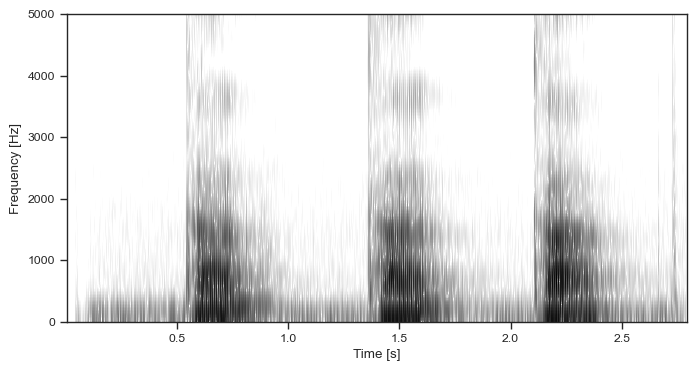

In [38]:
plt.figure(figsize=(8, 4))
draw_spectrogram(spectrogram)
plt.show()

Now we can add pitch contours to the spectrogram. Let's extract the pitch contour first:

In [39]:
pitch = snd.to_pitch()

In [40]:
def draw_pitch(pitch):
    pitch_values = pitch.selected_array['frequency'] # extract the pitch values
    pitch_values[pitch_values==0] = np.nan # set 0 values to NaN for better plotting
    plt.plot(pitch.xs(), pitch_values, 'o', markersize=5, color='red') # plot the pitch values
    plt.ylim(0, pitch.ceiling) # limit the y-axis to the possible pitch range
    plt.ylabel("Fundamental frequency [Hz]") # set the y-axis label

/var/folders/1c/pphtjl397rnbdcp94xmwzkqr0000gn/T/ipykernel_47003/3585317524.py:3: RuntimeWarning: divide by zero encountered in log10
  sg_db = 10 * np.log10(spectrogram.values) # convert the intensity to dB


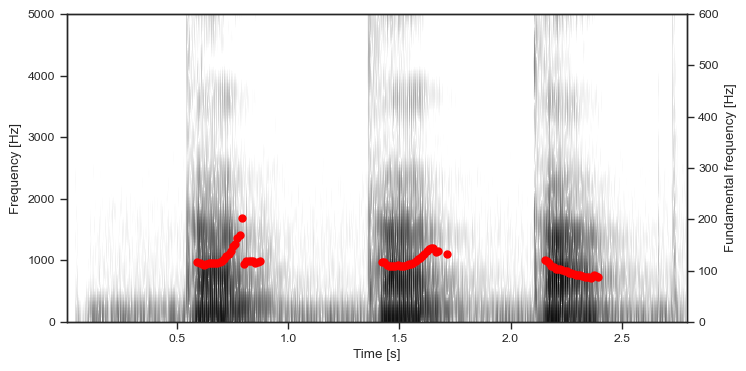

In [41]:
plt.figure(figsize=(8, 4)) # define the figure size
draw_spectrogram(spectrogram) # plot the spectrogram
plt.twinx() # create a twin Axes sharing the xaxis (to plot fundamental frequency for pitch)
draw_pitch(pitch) # plot the pitch
plt.show() # show the plot

Why do we only have pitch values for some of the frames?

**Answer:** Pitch is defined for voiced, periodic frames. Silence and unvoiced consonants have no reliable fundamental frequency, so the pitch tracker returns zero there.


## 3. English vowels and their formants

We are going to use the data on vowel formants from [here](https://www.phon.ucl.ac.uk/courses/pals0039/datasets.php). It contains data on English vowels produced by 44 speakers (31 female, 13 male) . The data is stored in the file `vowels.csv`.

### 3.1. Data & summary statistics

Let's start by reading the data:

In [42]:
vowels = pd.read_csv('vowels.csv')

Let's see how the data looks like:

In [43]:
vowels.head(10)

,SPEAKER,WORD,VOWEL,F1,F2,SEX,HEIGHT
0,S1,bad,æ,848.070,1450.960,male,173
1,S1,bard,ɑ,648.318,1126.220,male,173
2,S1,bead,i,259.000,1834.000,male,173
3,S1,bed,e,578.985,1715.220,male,173
4,S1,bid,ɪ,405.000,1899.000,male,173
5,S1,bird,ɜ,656.600,1414.400,male,173
6,S1,board,ɔ,360.034,988.693,male,173
7,S1,bod,ɒ,513.689,1023.000,male,173
8,S1,booed,u,277.000,1461.000,male,173
9,S1,bud,ʌ,592.313,1278.600,male,173


What can you tell from the data? What units of measurement are used for the formants? How many vowels are there? How many speakers?

**Answer:** The table has 484 rows from 44 speakers (31 female and 13 male) producing 11 vowels. F1 and F2 are measured in hertz.


Let's count how many unique speakers are in the data:

In [44]:
vowels['SPEAKER'].nunique()

44

Count the number of male and female speakers:

In [45]:
vowels.groupby('SEX')['SPEAKER'].nunique()

SEX
female    31
male      13
Name: SPEAKER, dtype: int64

Plot it as a bar chart:

<Axes: xlabel='SEX'>

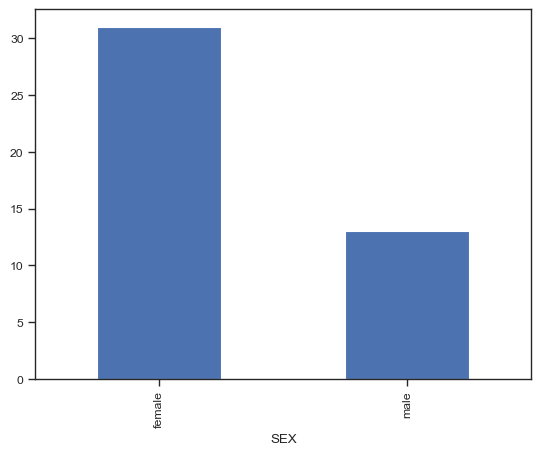

In [46]:
vowels.groupby('SEX')['SPEAKER'].nunique().plot.bar()

Plot a distribution of heights (note that each speaker produced multiple vowels).

<Axes: ylabel='Density'>

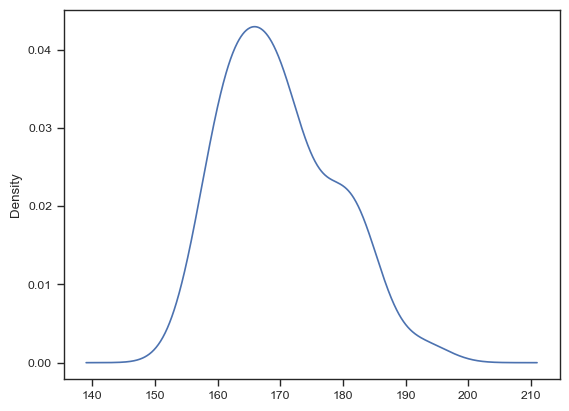

In [47]:
vowels.drop_duplicates(subset='SPEAKER')['HEIGHT'].plot.density()

SEX
female    Axes(0.125,0.11;0.775x0.77)
male      Axes(0.125,0.11;0.775x0.77)
Name: HEIGHT, dtype: object

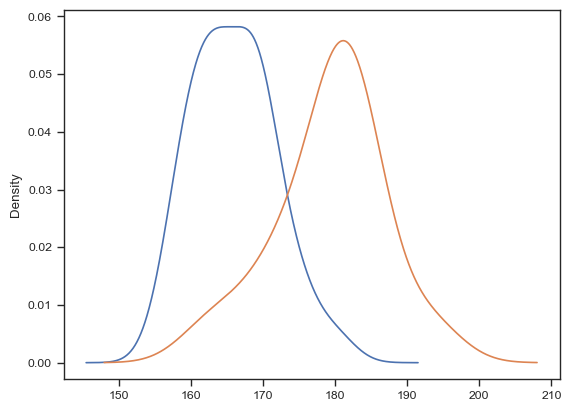

In [48]:
vowels.drop_duplicates(subset='SPEAKER').groupby('SEX')['HEIGHT'].plot.density()

Can you do the same, but by gender? Hint: plot the mean values instead of individual data points (you can use the [pointplot](https://seaborn.pydata.org/generated/seaborn.pointplot.html) function from seaborn).

<Axes: xlabel='SEX', ylabel='HEIGHT'>

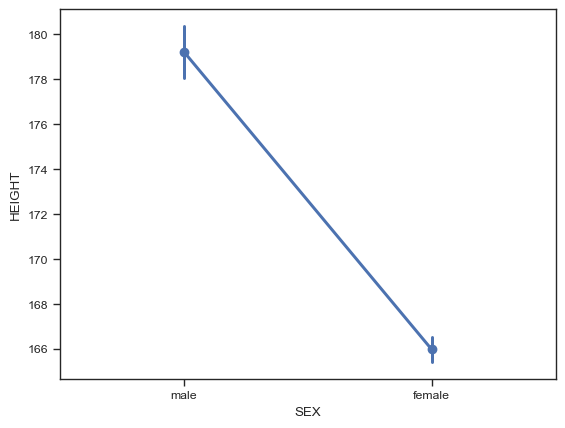

In [49]:
sns.pointplot(x='SEX', y='HEIGHT', data=vowels)

### 3.2. Representing the vowel space

Let's plot a scatter plot of the first two formants of the vowels. For now, we can plot all of the vowels in the same plot.

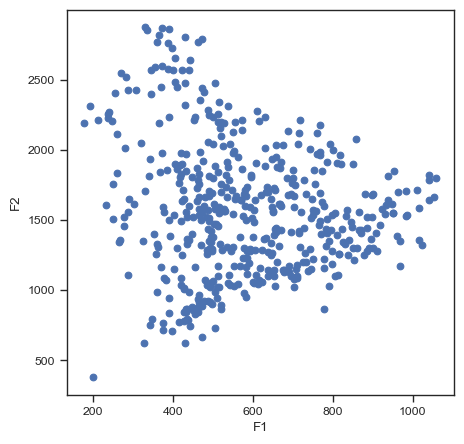

In [50]:
plt.figure(figsize=(5, 5)) # set the size of the plot
plt.scatter(vowels['F1'], vowels['F2']) # create a scatter plot
plt.xlabel('F1') # set the x-axis label
plt.ylabel('F2') # set the y-axis label
plt.show() # show the plot

That's a bit messy. First, we cannot distinguish the different vowels. We can fix that by plotting each vowel with unique color. Hint: use the label argument of the `scatter` function.

In [51]:
?sns.scatterplot

Signature:
sns.scatterplot(
    data=None,
    *,
    x=None,
    y=None,
    hue=None,
    size=None,
    style=None,
    palette=None,
    hue_order=None,
    hue_norm=None,
    sizes=None,
    size_order=None,
    size_norm=None,
    markers=True,
    style_order=None,
    legend='auto',
    ax=None,
    **kwargs,
)
Docstring:
Draw a scatter plot with possibility of several semantic groupings.

The relationship between `x` and `y` can be shown for different subsets
of the data using the `hue`, `size`, and `style` parameters. These
parameters control what visual semantics are used to identify the different
subsets. It is possible to show up to three dimensions independently by
using all three semantic types, but this style of plot can be hard to
interpret and is often ineffective. Using redundant semantics (i.e. both
`hue` and `style` for the same variable) can be helpful for making
graphics more accessible.

See the :ref:`tutorial <relational_tutorial>` for more information.

The de

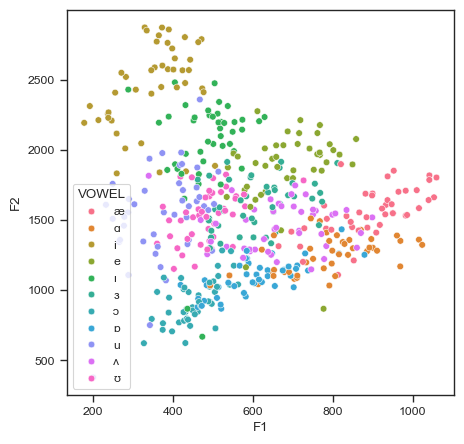

In [52]:
plt.figure(figsize=(5, 5)) # set the size of the plot
sns.scatterplot(x='F1', y='F2', hue='VOWEL', data=vowels)
plt.xlabel('F1') # set the x-axis label
plt.ylabel('F2') # set the y-axis label
plt.show() # show the plot

Ok, there is a slight problem with colors overlapping, so we are going to fix that by using a different color map. Hint: use the `cmap` argument of the `scatter` function, and use the `plt.cm.get_cmap` function to get a colormap with a large number of colors.

/var/folders/1c/pphtjl397rnbdcp94xmwzkqr0000gn/T/ipykernel_47003/263162225.py:1: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap = plt.cm.get_cmap('tab20')


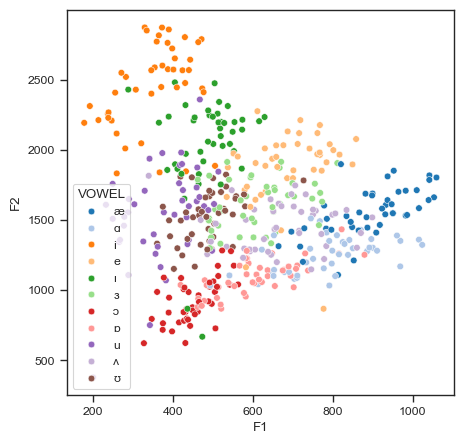

In [53]:
cmap = plt.cm.get_cmap('tab20')

plt.figure(figsize=(5, 5)) # set the size of the plot
sns.scatterplot(x='F1', y='F2', hue='VOWEL', 
                data=vowels, palette='tab20')
plt.xlabel('F1') # set the x-axis label
plt.ylabel('F2') # set the y-axis label
plt.show() # show the plot

What's wrong with the plot, compare it with the vowel chart below. What do you think is the problem?

**NB: the vowel chart below is for the California English dialect, but it should give you an idea of what the vowel space should look like.**

<!-- insert image from link -->

![vowel_chart](https://thumb.wikimedia.org/wikipedia/commons/thumb/0/08/California_English_vowel_chart.svg/3840px-California_English_vowel_chart.svg.png?utm_source=en.wikipedia.org&utm_campaign=imageinfo&utm_content=thumbnail){width=500px}

How can we change the chart to make it look more like the vowel chart? Pay attention to the axes and sounds like [i]. Hint: you can use invert axes by calling `plt.gca().invert_xaxis()` or `plt.gca().invert_yaxis()` for x and y axes respectively. We also probably would need to change the x and y axes data.

**Answer:** A vowel chart puts F2 on the horizontal axis and F1 on the vertical axis, with both axes reversed. This places high/front vowels such as [i] toward the upper left.


/var/folders/1c/pphtjl397rnbdcp94xmwzkqr0000gn/T/ipykernel_47003/3423146743.py:1: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap = plt.cm.get_cmap('tab20')


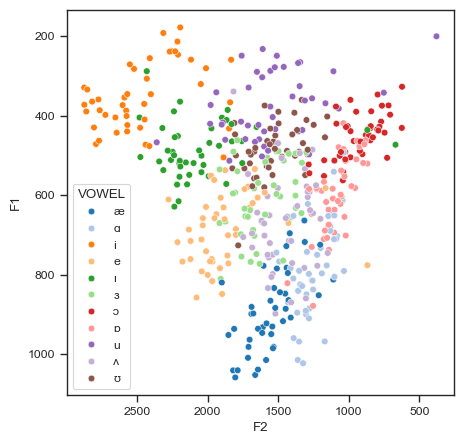

In [54]:
cmap = plt.cm.get_cmap('tab20')

plt.figure(figsize=(5, 5)) # set the size of the plot
sns.scatterplot(x='F2', y='F1', hue='VOWEL', 
                data=vowels, palette='tab20')
plt.gca().invert_xaxis()
plt.gca().invert_yaxis()
plt.xlabel('F2') # set the x-axis label
plt.ylabel('F1') # set the y-axis label
plt.show() # show the plot

This is a representation of how every individual speaker produces the vowels, but we can also represent the average formants for each vowel (by modifying the previous plot to compute average formants per formant). Let's do that. Note that you could use the pandas .mean() method to compute the average formant frequencies.

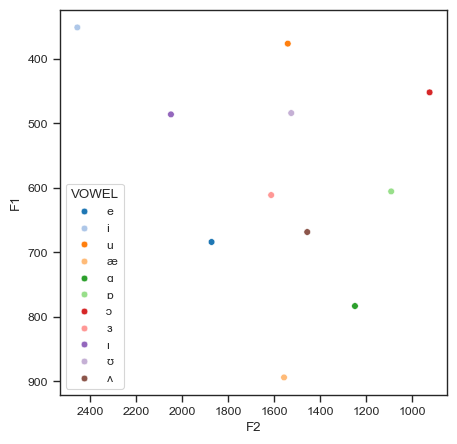

In [55]:
vowels2 = vowels.groupby('VOWEL')[['F1', 'F2']].mean().reset_index()
plt.figure(figsize=(5, 5)) # set the size of the plot
sns.scatterplot(x='F2', y='F1', hue='VOWEL', 
                data=vowels2, palette='tab20')
plt.gca().invert_xaxis()
plt.gca().invert_yaxis()
plt.xlabel('F2') # set the x-axis label
plt.ylabel('F1') # set the y-axis label
plt.show() # show the plot

Finally, we can make everything look nicer by positioning the axes on the top and right sides, and using the seaborn [scatterplot](https://seaborn.pydata.org/generated/seaborn.scatterplot.html) function.

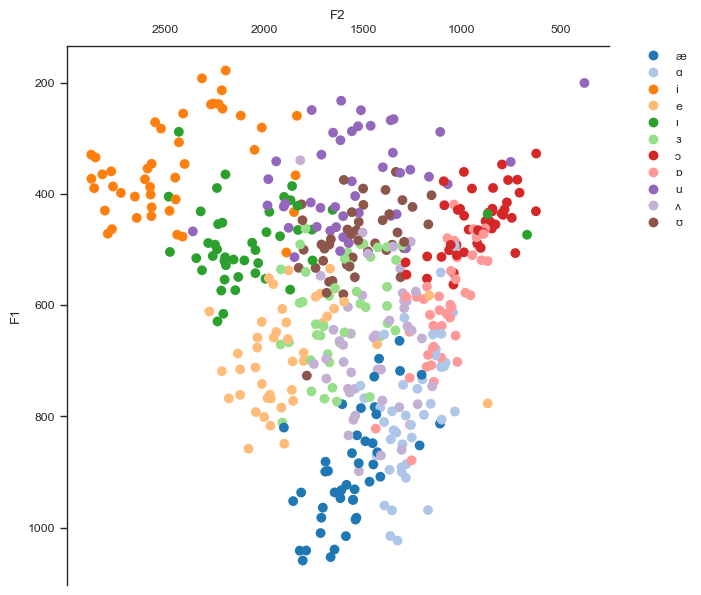

In [56]:
plt.figure(figsize=(7, 7))
sns.scatterplot(data=vowels, 
                x='F2', y='F1', 
                hue='VOWEL', 
                palette='tab20',
                s=50,
                linewidth=0)
# reverse the y-axis
plt.gca().invert_yaxis()
# reverse the x-axis
plt.gca().invert_xaxis()
# put x axis on top 
plt.gca().xaxis.set_label_position('top')
plt.gca().xaxis.set_ticks_position('top')
plt.legend(bbox_to_anchor=(1.05, 1), 
           loc=2, 
           borderaxespad=0., 
           frameon=False)
sns.despine(bottom=True, right=True, top=False, left=False) # let's remove the splines without ticks
# remove bottom and right spines
plt.show()

You can improve this plot by using different shapes for males and females, for that you can use the `style` parameter in the scatterplot function. You can also have two separate subplots for males and females (hint: use `plt.subplots` to create subplots).

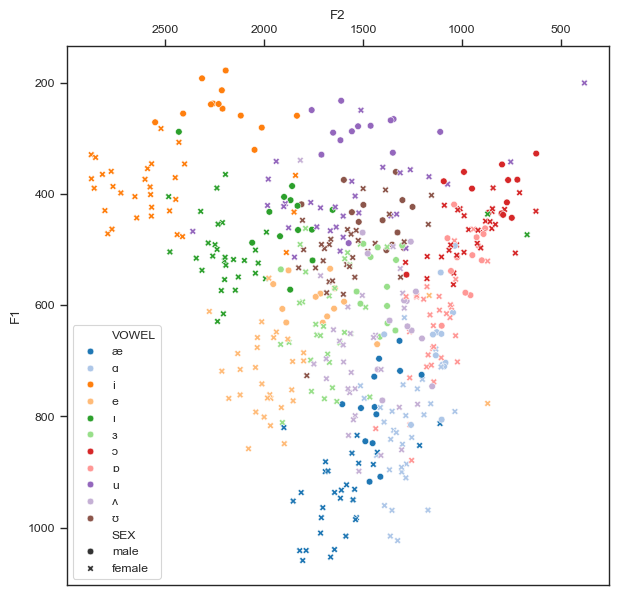

In [57]:
plt.figure(figsize=(7, 7))
sns.scatterplot(data=vowels, x='F2', y='F1', hue='VOWEL', style='SEX', palette='tab20')
plt.gca().invert_xaxis()
plt.gca().invert_yaxis()
plt.gca().xaxis.set_ticks_position('top')
plt.gca().xaxis.set_label_position('top')
plt.show()


You can also make the size proportional to the height of the speaker. You can do that by using the `size` parameter in the scatterplot function. NB: that you can scale the size by adding the `sizes' parameter, which should be an interval like (20, 100) -- you should experiment with that. 

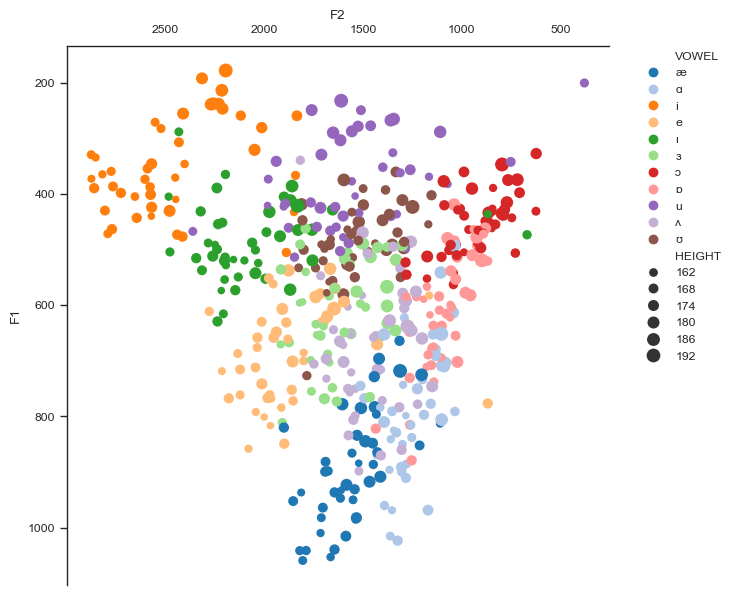

In [58]:
plt.figure(figsize=(7, 7))
sns.scatterplot(data=vowels, 
                x='F2', y='F1', 
                hue='VOWEL', 
                palette='tab20',
                size='HEIGHT',
                s=50,
                linewidth=0,
                sizes = (30, 100))
# reverse the y-axis
plt.gca().invert_yaxis()
# reverse the x-axis
plt.gca().invert_xaxis()
# put x axis on top 
plt.gca().xaxis.set_label_position('top')
plt.gca().xaxis.set_ticks_position('top')
plt.legend(bbox_to_anchor=(1.05, 1), 
           loc=2, 
           borderaxespad=0., 
           frameon=False)
sns.despine(bottom=True, right=True, top=False, left=False) # let's remove the splines without ticks
# remove bottom and right spines
plt.show()

### 3.3. Predicting the vowel from the formants

In [59]:
from sklearn.model_selection import train_test_split # split the data into training and testing sets
from sklearn.metrics import accuracy_score # calculate accuracy
from sklearn.ensemble import RandomForestClassifier # random forest classifier

First, we need to split the data into the predictors (x) and the target (y). The predictors are the formants, and the target is the vowel label.

In [60]:
x = vowels[['F1', 'F2']]
y = vowels['VOWEL']

Then we need to scale the data, so that the formants on the same scale. We can do it by subtracting the mean and dividing by the standard deviation. That way, for each formant (F1 or F2), their value would correspond the difference in number of standard deviations from the mean. Let's write the formula below as a function.

$\text{standard score}(x) = \frac{x - \mu}{\sigma}$

In [61]:
def scaler(x):
    return (x - x.mean()) / x.std()

Then apply it to each row in the x data. We can use the pandas `apply` method for that (you can read more about it [here](https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.DataFrame.apply.html)).

In [62]:
x_scaled = x.apply(scaler, axis=0)

Let's check the data:

In [63]:
x_scaled

,F1,F2
0,1.437650,-0.265693
1,0.361257,-0.955811
2,-1.736640,0.548321
3,-0.012354,0.295897
4,-0.949898,0.686455
...,...,...
479,-0.869068,-1.037034
480,0.181718,-1.060411
481,-0.896011,0.399561
482,1.501936,-0.578004


What should be the mean of the each transformed formant?

**Answer:** Approximately zero for both F1 and F2, apart from floating-point rounding.


In [64]:
x_scaled.mean()

F1   -5.982359e-16
F2   -8.055998e-16
dtype: float64

Ok, now let's split the transformed data into training and testing sets. We can use 80% of the data for training and 20% for testing. We can also set the random state, so that our results are reproducible. You can read more about this here: [train_test_split](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.train_test_split.html).

In [65]:
x_train, x_test, y_train, y_test = train_test_split(x_scaled, y,
                                                    test_size=0.2, 
                                                    random_state=42,
                                                    stratify=y)

We want to classify vowels, so we have multiple classes. You are probably familiar with binary classification, but we can also classify multiple classes. You can read more about it [here](https://scikit-learn.org/stable/modules/multiclass.html). Today, we will be using the random forest classifier, which is essentially an ensemble of decision trees. You can read more about it [here](https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.RandomForestClassifier.html). We start by initializing the model with the default parameters.

In [66]:
# train a classifier model
model = RandomForestClassifier(random_state=42)

We need to fit the model first. Then we can predict the vowels for the test data.

In [67]:
model.fit(x_train, y_train)

RandomForestClassifier(random_state=42)

We can first start by checking the accuracy (i.e. how many times the model predicted the correct vowel). We can do it by comparing the predicted vowels with the true vowels.

In [68]:
y_pred_train = model.predict(x_train)

Let's look at the accuracy of the model on the training data:

In [69]:
accuracy_score(y_train, y_pred_train)

1.0

Let's try to predict the vowels for the test data. Test data is different, because the model hasn't seen it before. What do you think the accuracy will be? 

You will first need to predict the vowels for the test data and then calculate the accuracy.

**Answer:** The training examples were used to fit the model, so their accuracy is higher. Test accuracy is about 0.557 with this split and random seed.


In [70]:
y_pred = model.predict(x_test)

In [71]:
print(accuracy_score(y_test, y_pred))

0.5567010309278351


### 3.4. Predicting the vowel from the formants and the gender of the speaker

We need to convert the gender into binary machine readable features. For this, we can use pandas .map() method. You can read more about it [here](https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.Series.map.html).

In [72]:
vowels['SEX_b'] = vowels['SEX'].map({'male': 0, 'female': 1})

In [73]:
x = vowels[['F1', 'F2']]
x_genre = vowels[['SEX_b']]
y = vowels['VOWEL']

x_scaled = x.apply(scaler, axis=0)

x_new = pd.concat([x_scaled, x_genre], axis=1)

Let's do the same thing again with scaling the data, splitting the data into training and testing sets, and fitting the model. NB: you will need to do the scaling just on the formats, and the join the gender back after scaling.

In [74]:
x_train, x_test, y_train, y_test = train_test_split(x_new, y,
                                                    test_size=0.2, 
                                                    random_state=42,
                                                    stratify=y)

Let's fit the model again:

In [75]:
model = RandomForestClassifier(random_state=42)

model.fit(x_train, y_train)

RandomForestClassifier(random_state=42)

Let's start by evaluating the performance on testing set directly:

In [76]:
y_pred = model.predict(x_test)
print(accuracy_score(y_test, y_pred))

0.711340206185567


Did the accuracy improve? Why do you think that happened?

**Answer:** Yes. Test accuracy rises from about 0.557 to 0.711 when sex is included. Speakers of different sexes have systematically different formant ranges, so this feature helps classify vowels.


Let's look at the values of F1 per vowel per gender. What is going on here? Why do you think that is?

**Answer:** Female speakers have higher mean F1 and F2 for all 11 vowels in this dataset. The plots below show the difference by vowel.


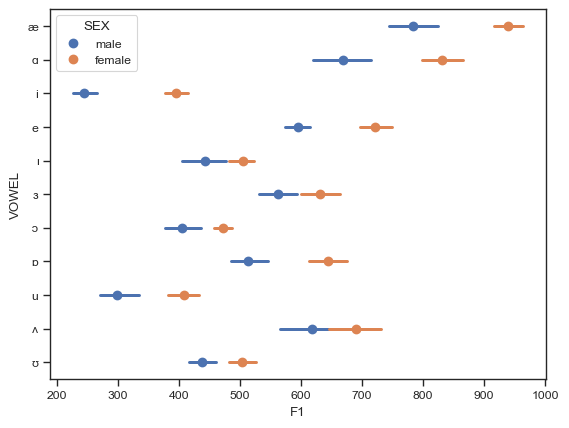

In [77]:
sns.pointplot(data=vowels, x='F1', y='VOWEL', hue='SEX', linestyles='none')
plt.show()


Then we can plot F2 as well:

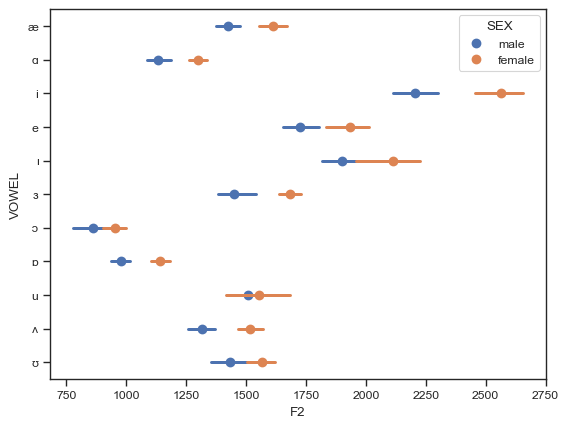

In [78]:
sns.pointplot(data=vowels, x='F2', y='VOWEL', hue='SEX', linestyles='none')
plt.show()


In this dataset, female speakers have higher average F1 and F2 for every vowel. This helps explain why the model performs better with speaker sex.


### 3.5. Predicting the vowel from the formants, gender and height of the speaker.

Finally, we can try to predict the vowels from the information about (a) formants, (b) gender and (c) height of the speaker. What would you need to standardize? Only the formants, or height as well? Create the preprocessed training and testing data:

**Answer:** Standardize the continuous measurements F1, F2, and HEIGHT. Keep the encoded binary sex variable as 0/1.


In [79]:
x = vowels[['F1', 'F2', 'HEIGHT']]
x_genre = vowels[['SEX_b']]
y = vowels['VOWEL']

x_scaled = x.apply(scaler, axis=0)

x_new = pd.concat([x_scaled, x_genre], axis=1)

Let's see how the training dataset looks like:

In [80]:
x_train, x_test, y_train, y_test = train_test_split(x_new, y,
                                                    test_size=0.2, 
                                                    random_state=42,
                                                    stratify=y)

x_train

,F1,F2,HEIGHT,SEX_b
38,0.574092,0.217628,-0.686694,1
89,1.055406,-0.890740,0.013257,1
211,-1.046419,2.127704,-0.453377,1
159,0.460160,0.633242,-0.220060,1
319,1.617571,0.240622,-0.220060,1
...,...,...,...,...
120,-0.919129,-0.586186,1.179841,0
335,0.363606,0.036693,-0.220060,1
338,-0.650451,0.637556,-0.220060,1
150,0.095931,-1.102106,-1.153327,1


Then fit the model again:

In [81]:
model = RandomForestClassifier(random_state=42)

model.fit(x_train, y_train)

RandomForestClassifier(random_state=42)

And finally, evaluate the model. Did the accuracy improve? What does it tell us.

**Answer:** No. Test accuracy falls from about 0.711 to 0.639 after adding height with this split and random seed.


In [82]:
y_pred = model.predict(x_test)

print(accuracy_score(y_test, y_pred))

0.6391752577319587


What do you notice? Did the accuracy improve? Can you explain why?

**Answer:** Height partly overlaps with information already present in formants and sex. With this split, adding it does not improve the model and may add noise. The plots below show how height relates to formants.


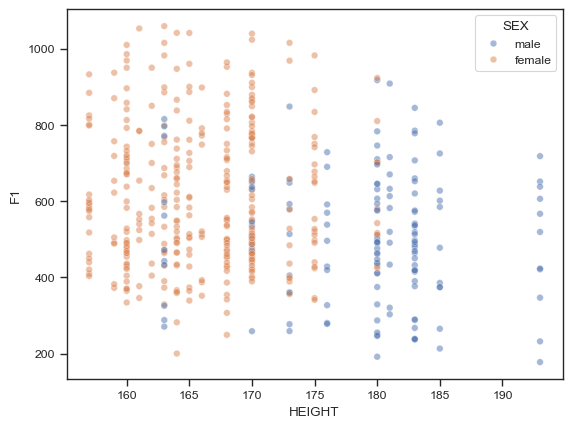

In [83]:
sns.scatterplot(data=vowels, x='HEIGHT', y='F1', hue='SEX', alpha=0.5)
plt.show()


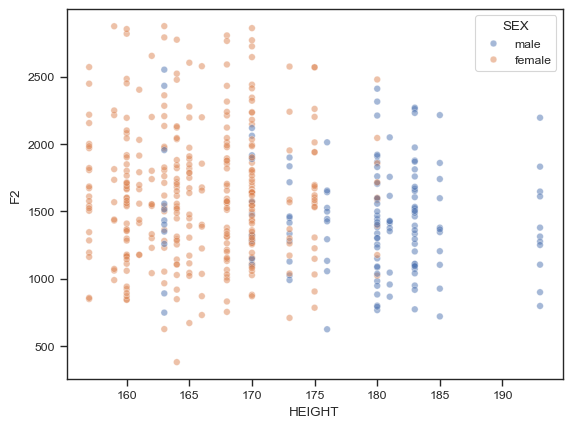

In [84]:
sns.scatterplot(data=vowels, x='HEIGHT', y='F2', hue='SEX', alpha=0.5)
plt.show()
